In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.gridspec import GridSpec

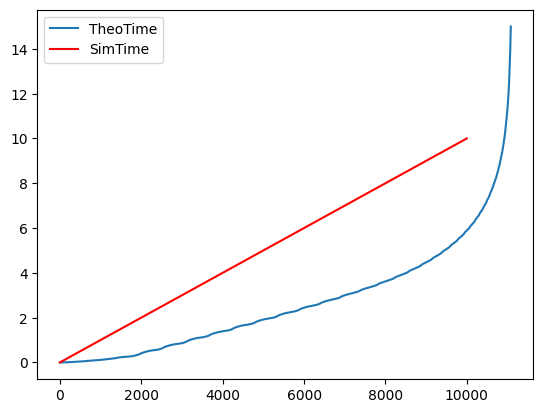

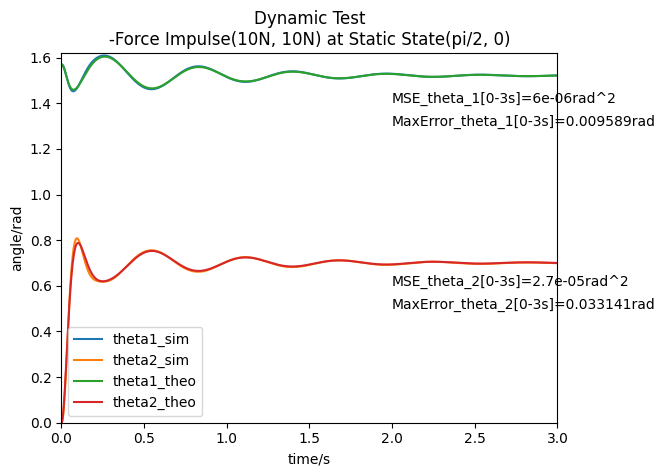

In [2]:

# 创建图形和三维轴
sim_data = np.load("../data/Exp-10N Force Pulse-20241226_224212/StaticState_list.npy")

t = scipy.io.loadmat("../AtoBMatlab/t.mat")['t']
theta_1 = scipy.io.loadmat("../AtoBMatlab/theta_1.mat")['theta_1']
theta_2 = scipy.io.loadmat("../AtoBMatlab/theta_2.mat")['theta_2']


# 时间并没有对齐
plt.plot(t, label="TheoTime")
plt.plot(sim_data[:,2]-10, 'r', label="SimTime")
plt.legend()
plt.show()

plt.plot(sim_data[:,2]-10, sim_data[:,3]+math.pi/2, label="theta1_sim")
plt.plot(sim_data[:,2]-10, sim_data[:,4], label="theta2_sim")
plt.plot(t, theta_1, label="theta1_theo")
plt.plot(t, theta_2, label="theta2_theo")
plt.legend()
plt.xlabel("time/s")
plt.ylabel("angle/rad")
plt.xlim([0, 3])
plt.ylim([0, 1.62])


# cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
t_intervel = np.linspace(0, 3, 300)
theta1_sim_intervel = np.interp(t_intervel, sim_data[:,2]-10, sim_data[:,3]+math.pi/2)
theta2_sim_intervel = np.interp(t_intervel, sim_data[:,2]-10, sim_data[:,4])
theta1_theo_intervel = np.interp(t_intervel, t.flatten(), theta_1.flatten())
theta2_theo_intervel = np.interp(t_intervel, t.flatten(), theta_2.flatten())

mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel))
mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel))
maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))


plt.text(2, 1.4, f"MSE_theta_1[0-3s]={round(mse_theta1, 6)}rad^2")
plt.text(2, 1.3, f"MaxError_theta_1[0-3s]={round(maxerror_theta1, 6)}rad")
plt.text(2, 0.6, f"MSE_theta_2[0-3s]={round(mse_theta2, 6)}rad^2")
plt.text(2, 0.5, f"MaxError_theta_2[0-3s]={round(maxerror_theta2, 6)}rad")


plt.title("Dynamic Test\n-Force Impulse(10N, 10N) at Static State(pi/2, 0)")

plt.show()



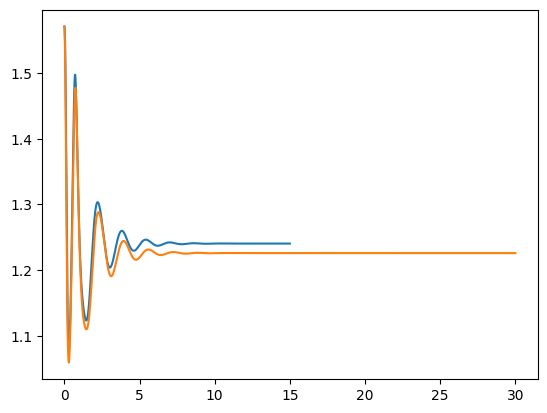

<function matplotlib.pyplot.show(close=None, block=None)>

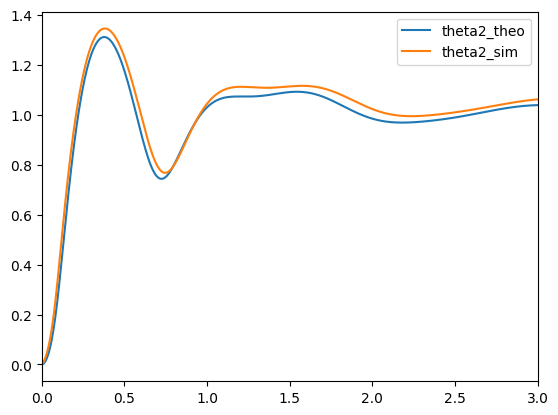

In [3]:
# Landing Model 2DOF 单点动力学

# 创建图形和三维轴
sim_data = np.load("../data/Exp-landing 10-20N Force Pulse-20250103_013557/StaticState_list.npy")

t = scipy.io.loadmat("../AtoBMatlab/landing/data/t.mat")['t']
Xt = scipy.io.loadmat("../AtoBMatlab/landing/data/Xt.mat")['Xt']
Xt.shape
theta_1 = Xt[:, 0]
theta_2 = Xt[:, 1]
plt.plot(t, theta_1, label="theta1_theo")
# sim_data: 0-F1, 1-F2, 2-time, 3-Hori, 4-Connec, 5-Theta1, 6-Theta2
plt.plot(sim_data[:,2], sim_data[:,5]+math.pi/2, label="theta1_sim")
plt.show()

plt.plot(t, theta_2, label="theta2_theo")
# sim_data: 0-F1, 1-F2, 2-time, 3-Hori, 4-Connec, 5-Theta1, 6-Theta2
plt.plot(sim_data[:,2], sim_data[:,6], label="theta2_sim")
plt.legend()
plt.xlim([0, 3])
plt.show

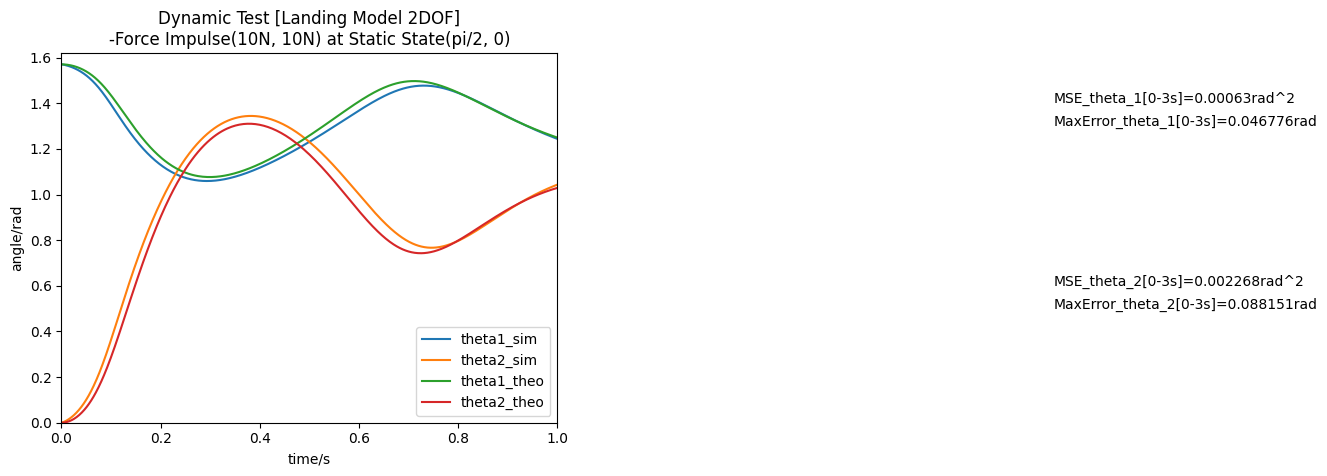

In [4]:
plt.plot(sim_data[:,2], sim_data[:,5]+math.pi/2, label="theta1_sim")
plt.plot(sim_data[:,2], sim_data[:,6], label="theta2_sim")
plt.plot(t, theta_1, label="theta1_theo")
plt.plot(t, theta_2, label="theta2_theo")
plt.legend()
plt.xlabel("time/s")
plt.ylabel("angle/rad")
plt.xlim([0, 1])
plt.ylim([0, 1.62])


# cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
t_intervel = np.linspace(0, 1, 800)
theta1_sim_intervel = np.interp(t_intervel, sim_data[:,2], sim_data[:,5]+math.pi/2)
theta2_sim_intervel = np.interp(t_intervel, sim_data[:,2], sim_data[:,6])
theta1_theo_intervel = np.interp(t_intervel, t.flatten(), theta_1.flatten())
theta2_theo_intervel = np.interp(t_intervel, t.flatten(), theta_2.flatten())

mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel))
mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel))
maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))


plt.text(2, 1.4, f"MSE_theta_1[0-3s]={round(mse_theta1, 6)}rad^2")
plt.text(2, 1.3, f"MaxError_theta_1[0-3s]={round(maxerror_theta1, 6)}rad")
plt.text(2, 0.6, f"MSE_theta_2[0-3s]={round(mse_theta2, 6)}rad^2")
plt.text(2, 0.5, f"MaxError_theta_2[0-3s]={round(maxerror_theta2, 6)}rad")


plt.title("Dynamic Test [Landing Model 2DOF]\n-Force Impulse(10N, 10N) at Static State(pi/2, 0)")

plt.show()

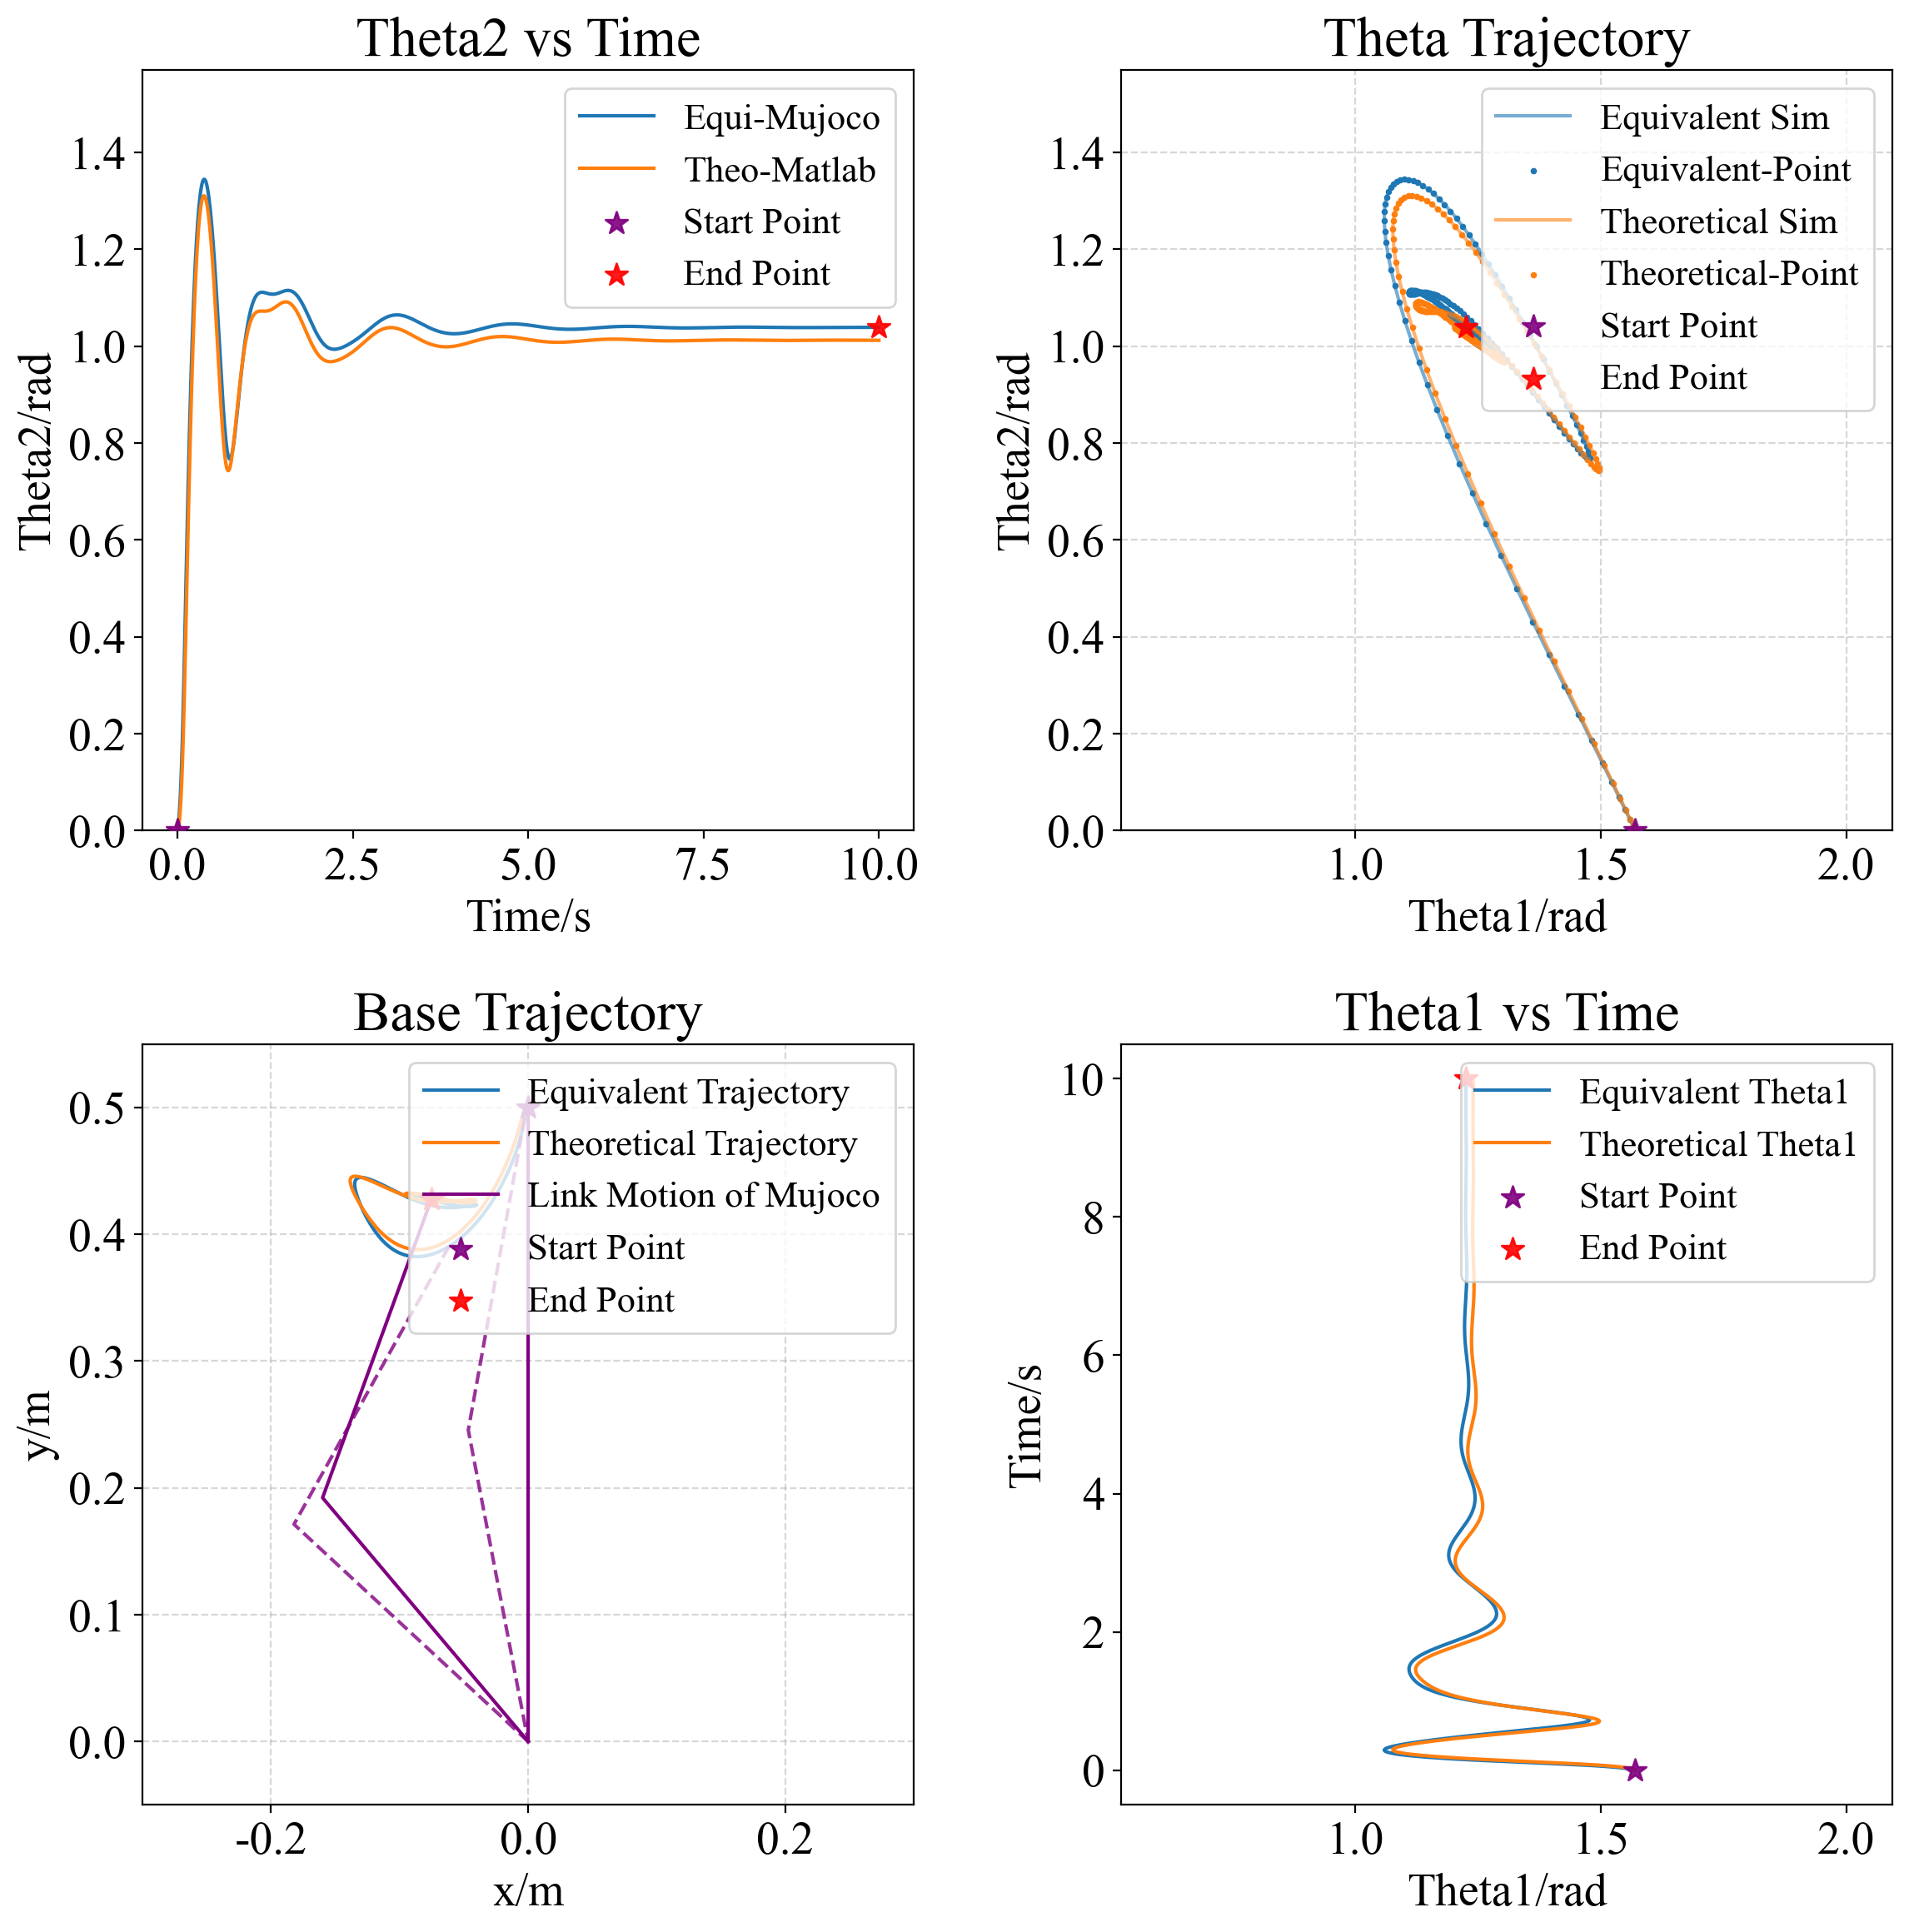

In [ ]:


# # 创建滑动条
# si_slider = widgets.IntSlider(value=22, min=0, max=99, step=1, description='StartPoint_index')
# ei_slider = widgets.IntSlider(value=55, min=0, max=99, step=1, description='EndPoint_index')

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 16,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 12,
}

# 绘图函数
def update_plot():
    # 获取数据
    t_mujoco, theta1_mujoco, theta2_mujoco = sim_data[:,2], sim_data[:,5]+math.pi/2, sim_data[:,6]
    t_matlab, theta1_matlab, theta2_matlab = t.flatten(), theta_1.flatten(), theta_2.flatten()
    

    # 0-10做插值
    t_interp = np.linspace(0, 10, 1000)
    theta1_mujoco = np.interp(t_interp, t_mujoco, theta1_mujoco)
    theta2_mujoco = np.interp(t_interp, t_mujoco, theta2_mujoco)
    theta1_matlab = np.interp(t_interp, t_matlab, theta1_matlab)
    theta2_matlab = np.interp(t_interp, t_matlab, theta2_matlab)    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200)  # 两行两列的图布局
    
    # --- 左上：时间曲线 ---
    # axs[0, 0].plot(t_interp, theta1_mujoco, label='Mujoco theta1')
    axs[0, 0].plot(t_interp, theta2_mujoco, label='Equi-Mujoco')
    # axs[0, 0].plot(t_interp, theta1_matlab, label='Matlab theta1')
    axs[0, 0].plot(t_interp, theta2_matlab, label='Theo-Matlab')
    axs[0, 0].set_xlabel('Time/s')
    axs[0, 0].set_ylabel('Theta2/rad')
    axs[0, 0].set_title('Theta2 vs Time')

    # 绘制角度限制横线
    # axs[0, 0].axhline(y=math.pi*2/3, color='r', linestyle='--', label='Theta1 Limit')
    # axs[0, 0].axhline(y=math.pi/6, color='r', linestyle='--', label='Theta2 Limit')
    # axs[0, 0].axhline(y=math.pi/2, color='b', linestyle='--', label='Theta2 Zero')
    # axs[0, 0].axhline(y=0, color='b', linestyle='--', label='Theta1 Start')

    # 标注起始点
    axs[0, 0].scatter(t_interp[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].scatter(t_interp[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].legend(**legendSet)

    edge = math.pi/6 * 0
    axs[0, 0].set_ylim([0, math.pi/2])
    
    # --- 右上：轨迹图 ---
    axs[0, 1].plot(theta1_mujoco, theta2_mujoco, label='Equivalent Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_mujoco, theta2_mujoco, s=3, label='Equivalent-Point')  # 散点

    axs[0, 1].plot(theta1_matlab, theta2_matlab, label='Theoretical Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_matlab, theta2_matlab, s=3, label='Theoretical-Point')  # 散点


    # 绘制角度方格——一个方形        
    # rect = plt.Rectangle((math.pi/6, 0), math.pi*2/3-math.pi/6, math.pi/2, linewidth=1, edgecolor='r', facecolor='none')
    # axs[0, 1].add_patch(rect)
    
    axs[0, 1].set_xlabel('Theta1/rad')
    axs[0, 1].set_ylabel('Theta2/rad')
    axs[0, 1].set_title('Theta Trajectory')
    axs[0, 1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[0, 1].set_ylim([0-edge, math.pi/2+edge])
    # axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)

    # end point 
    axs[0, 1].scatter(theta1_mujoco[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].scatter(theta1_mujoco[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    
    axs[0, 1].legend(**legendSet)

    
    # --- 左下：a_1cos(theta1) + a_2cos(theta2) ---
    a1 = 0.25  # 你可以根据需要调整
    a2 = 0.25  # 你可以根据需要调整
    # 以endpoint为偏置量，再取反向

    flip = -1  # You can adjust this value as needed

    x_mujoco = (a1 * np.cos(theta1_mujoco) + a2 * np.cos(theta2_mujoco + theta1_mujoco))
    y_mujoco = (a1 * np.sin(theta1_mujoco) + a2 * np.sin(theta2_mujoco + theta1_mujoco))
    x_matlab = (a1 * np.cos(theta1_matlab) + a2 * np.cos(theta2_matlab + theta1_matlab))
    y_matlab = (a1 * np.sin(theta1_matlab) + a2 * np.sin(theta2_matlab + theta1_matlab))

    knee_x_mujoco = (a1 * np.cos(theta1_mujoco))
    knee_y_mujoco = (a1 * np.sin(theta1_mujoco))
    knee_x_matlab = (a1 * np.cos(theta1_matlab))
    knee_y_matlab = (a1 * np.sin(theta1_matlab))

    zero_ = np.zeros_like(knee_x_mujoco)

    base_x_mujoco = zero_ - x_mujoco
    base_y_mujoco = zero_ - y_mujoco
    base_x_matlab = zero_ - x_matlab
    base_y_matlab = zero_ - y_matlab

    knee_x_mujoco = knee_x_mujoco - x_mujoco
    knee_y_mujoco = knee_y_mujoco - y_mujoco
    knee_x_matlab = knee_x_matlab - x_matlab
    knee_y_matlab = knee_y_matlab - y_matlab

    x_mujoco = x_mujoco - x_mujoco
    y_mujoco = y_mujoco - y_mujoco
    x_matlab = x_matlab - x_matlab
    y_matlab = y_matlab - y_matlab

    # flip
    x_mujoco = x_mujoco * flip
    y_mujoco = y_mujoco * flip
    x_matlab = x_matlab * flip
    y_matlab = y_matlab * flip
    knee_x_mujoco = knee_x_mujoco * flip
    knee_y_mujoco = knee_y_mujoco * flip
    knee_x_matlab = knee_x_matlab * flip
    knee_y_matlab = knee_y_matlab * flip
    base_x_mujoco = base_x_mujoco * flip
    base_y_mujoco = base_y_mujoco * flip
    base_x_matlab = base_x_matlab * flip
    base_y_matlab = base_y_matlab * flip


    axs[1, 0].plot(base_x_mujoco, base_y_mujoco, label='Equivalent Trajectory')
    axs[1, 0].plot(base_x_matlab, base_y_matlab, label='Theoretical Trajectory')

    # interesting point
    index_interesting = [0, -1, len(t_interp)//30, len(t_interp)//100]
    
    for index in index_interesting:
        # axs[1, 0].plot(np.array([zero_[index], knee_x_mujoco[index], x_mujoco[index]])-x_mujoco[index], np.array([zero_[index], knee_y_mujoco[index], y_mujoco[index]])-y_mujoco[index], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion of Mujoco")
        axs[1, 0].plot([base_x_mujoco[index], knee_x_mujoco[index], x_mujoco[index]], [base_y_mujoco[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion of Mujoco" if index==0 else "")

    # 标注起始点
    axs[1, 0].scatter(base_x_mujoco[0], base_y_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 0].scatter(base_x_mujoco[-1], base_y_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 0].set_xlabel('x/m')
    axs[1, 0].set_ylabel('y/m')

    axs[1, 0].set_xlim([-0.3, 0.3])
    axs[1, 0].set_ylim(np.array([-0.05, 0.55]))
    # equal
    # axs[1, 0].set_aspect('equal', adjustable='box')
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    axs[1, 0].set_title('Base Trajectory')
    axs[1, 0].legend(**legendSet)


    # --- 右下：theta2随时间变化 ---
    axs[1, 1].plot(theta1_mujoco, t_interp, label='Equivalent Theta1')
    axs[1, 1].plot(theta1_matlab, t_interp, label='Theoretical Theta1')

    axs[1, 1].set_xlabel('Theta1/rad')
    axs[1, 1].set_ylabel('Time/s')

    # 标注起始点
    axs[1, 1].scatter(theta1_mujoco[0], t_interp[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 1].scatter(theta1_mujoco[-1], t_interp[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 1].legend(**legendSet)
    axs[1, 1].set_title('Theta1 vs Time')
    axs[1, 1].set_xlim([math.pi/6, math.pi*2/3])

    # 设置每个子图的纵横比为相等的正方形
    

    plt.tight_layout()
    plt.show()

# # 显示交互绘图
# interactive_plot = widgets.interactive(update_plot, si=si_slider, ei=ei_slider)
# display(interactive_plot)
update_plot()

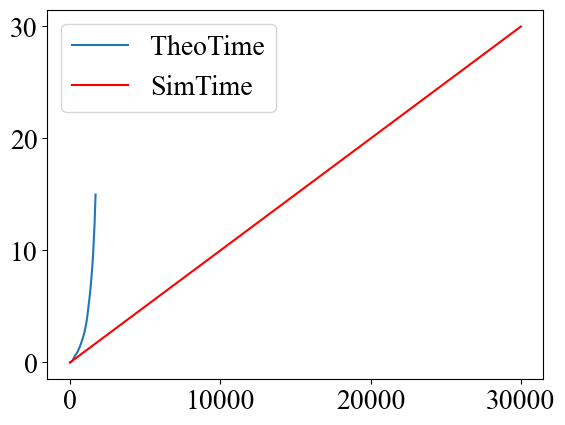

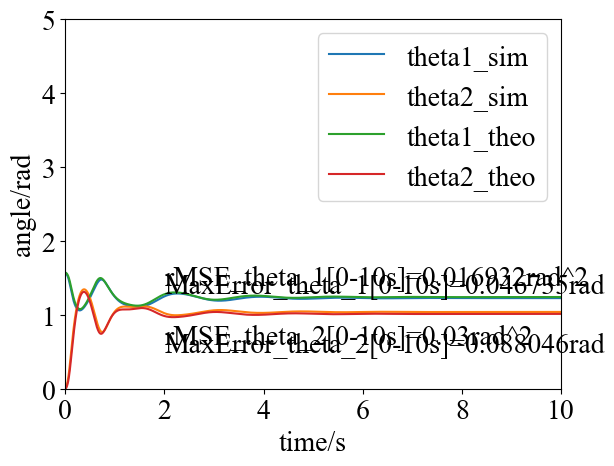

(np.float64(0.016932111326545908),
 np.float64(0.030000426189700044),
 np.float64(0.015463744357580921),
 np.float64(0.02828623697105045),
 np.float64(0.046734678258050444),
 np.float64(0.08804620535337354))

In [84]:
# copy
# 对比

def step_response_compare(t_array_matlab, theta1_array_matlab, theta2_array_matlab, t_array_mujoco, theta1_array_mujoco, theta2_array_mujoco, if_plot=True):
    # 时间并没有对齐
    if if_plot:
        plt.plot(t_array_matlab, label="TheoTime")
        plt.plot(t_array_mujoco, 'r', label="SimTime")
        plt.legend()
        plt.show()

        plt.plot(t_array_mujoco, theta1_array_mujoco, label="theta1_sim")
        plt.plot(t_array_mujoco, theta2_array_mujoco, label="theta2_sim")
        plt.plot(t_array_matlab, theta1_array_matlab, label="theta1_theo")
        plt.plot(t_array_matlab, theta2_array_matlab, label="theta2_theo")
        plt.legend()
        plt.xlabel("time/s")
        plt.ylabel("angle/rad")
        plt.xlim([0, 10])
        plt.ylim([0, 5])


    # cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
    t_intervel = np.linspace(0, 10, 1000)
    theta1_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta1_array_mujoco)
    theta2_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta2_array_mujoco)
    theta1_theo_intervel = np.interp(t_intervel, t_array_matlab, theta1_array_matlab)
    theta2_theo_intervel = np.interp(t_intervel, t_array_matlab, theta2_array_matlab)

    rmse_theta1 = np.sqrt(np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel)))
    rmse_theta2 = np.sqrt(np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel)))
    mae_theta1 = np.mean(np.abs(theta1_sim_intervel-theta1_theo_intervel))
    mae_theta2 = np.mean(np.abs(theta2_sim_intervel-theta2_theo_intervel))
    maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
    maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))

    if if_plot:
        plt.text(2, 1.4, f"rMSE_theta_1[0-10s]={round(rmse_theta1, 6)}rad^2")
        plt.text(2, 1.3, f"MaxError_theta_1[0-10s]={round(maxerror_theta1, 6)}rad")
        plt.text(2, 0.6, f"rMSE_theta_2[0-10s]={round(rmse_theta2, 6)}rad^2")
        plt.text(2, 0.5, f"MaxError_theta_2[0-10s]={round(maxerror_theta2, 6)}rad")

        plt.show()
    
    return rmse_theta1, rmse_theta2, mae_theta1, mae_theta2, maxerror_theta1, maxerror_theta2

t_mujoco, theta1_mujoco, theta2_mujoco = sim_data[:,2], sim_data[:,5]+math.pi/2, sim_data[:,6]
t_matlab, theta1_matlab, theta2_matlab = t.flatten(), theta_1.flatten(), theta_2.flatten()

step_response_compare(t_matlab, theta1_matlab, theta2_matlab, t_mujoco, theta1_mujoco, theta2_mujoco, if_plot=True)

# 导入实物数据 20250115
## 1 动态数据

In [7]:
file_path = "../data/realdata-2025-01-18/重要Static_2025-01-15_11-33-47_A2B_data.csv"
real_data = pd.read_csv(file_path)
print(real_data.head())

   relative_time  pressure1_start  pressure2_start  pressure1_end  \
0       0.020797              0.0              0.0            0.0   
1       0.029251              0.0              0.0            0.0   
2       0.037705              0.0              0.0            0.0   
3       0.046149              0.0              0.0            0.0   
4       0.054592              0.0              0.0            0.0   

   pressure2_end    base_x    base_y  base_theta10  thigh_theta20  \
0            0.0  0.251659  0.524568      0.430318      72.810369   
1            0.0  0.251659  0.524568      0.430318      72.810369   
2            0.0  0.251659  0.524568      0.430318      72.810369   
3            0.0  0.251659  0.524568      0.430318      72.810369   
4            0.0  0.251659  0.524568      0.430318      72.810369   

   thigh_theta21  calf_theta30  calf_theta32  
0      72.382098     44.923306     62.165229  
1      72.382098     44.923306     62.165229  
2      72.382098     44.92330

In [8]:
real_data[(real_data['pressure1_start']==25000) & (real_data['pressure2_start']==25000)]

,relative_time,pressure1_start,pressure2_start,pressure1_end,pressure2_end,base_x,base_y,base_theta10,thigh_theta20,thigh_theta21,calf_theta30,calf_theta32
21135,0.020183,25000.0,25000.0,0.0,0.0,0.247387,0.524171,0.328460,93.490006,93.158516,3.084827,-0.408634
21136,0.028630,25000.0,25000.0,0.0,0.0,0.247387,0.524171,0.328460,93.490006,93.158516,3.084827,-0.408634
21137,0.037073,25000.0,25000.0,0.0,0.0,0.247387,0.524171,0.328460,93.490006,93.158516,3.084827,-0.408634
21138,0.045517,25000.0,25000.0,0.0,0.0,0.247387,0.524171,0.328460,93.490006,93.158516,3.084827,-0.408634
21139,0.054307,25000.0,25000.0,0.0,0.0,0.247387,0.524171,0.328460,93.490006,93.158516,3.084827,-0.408634
...,...,...,...,...,...,...,...,...,...,...,...,...
26416,4.960910,25000.0,25000.0,50000.0,50000.0,0.246177,0.524125,0.342835,87.122560,86.712797,-4.463090,-1.532314
26417,4.969362,25000.0,25000.0,50000.0,50000.0,0.246166,0.524106,0.368164,87.088256,86.715693,-4.411415,-1.518139
26418,4.977808,25000.0,25000.0,50000.0,50000.0,0.246166,0.524106,0.368164,87.088256,86.715693,-4.411415,-1.518139
26419,4.986250,25000.0,25000.0,50000.0,50000.0,0.246166,0.524106,0.368164,87.088256,86.715693,-4.411415,-1.518139


3522    0.074284
3523    0.082756
3524    0.091202
3525    0.099663
3526    0.108106
          ...   
3635    1.031790
3636    1.040558
3637    1.049003
3638    1.057446
3639    1.065802
Name: relative_time, Length: 118, dtype: float64

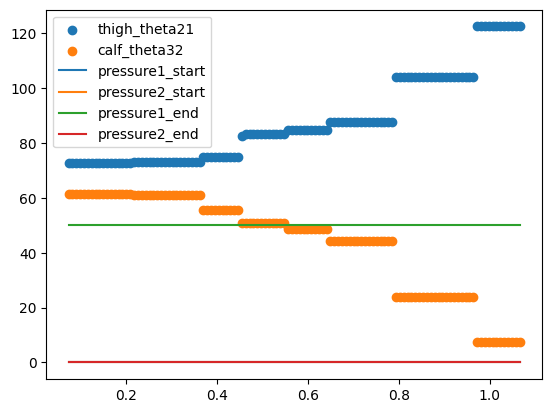

In [9]:
aprox_index_of_group = int(len(real_data["relative_time"])/81)

index_of_interest = np.arange(6*aprox_index_of_group, 6.2*aprox_index_of_group)
plt.scatter(real_data["relative_time"][index_of_interest], real_data["thigh_theta21"][index_of_interest], label="thigh_theta21")
plt.scatter(real_data["relative_time"][index_of_interest], real_data["calf_theta32"][index_of_interest], label="calf_theta32")
# pressure
plt.plot(real_data["relative_time"][index_of_interest], real_data["pressure1_start"][index_of_interest]/1000, label="pressure1_start")
plt.plot(real_data["relative_time"][index_of_interest], real_data["pressure2_start"][index_of_interest]/1000, label="pressure2_start")
plt.plot(real_data["relative_time"][index_of_interest], real_data["pressure1_end"][index_of_interest]/1000, label="pressure1_end")
plt.plot(real_data["relative_time"][index_of_interest], real_data["pressure2_end"][index_of_interest]/1000, label="pressure2_end")

plt.legend()
real_data["relative_time"][index_of_interest]

## 2 静态多组结果（未滤除可能存在的传感丢失数据）


In [10]:
# static scan
file_path = "../data/realdata-2025-01-18/Static_2025-01-15_13-58-01_real-静力学实验_data.csv"
real_data = pd.read_csv(file_path)
print(real_data.head())

   relative_time  pressure_command1  pressure_command2   base_x    base_y  \
0       0.020136                0.0                0.0  0.22452  0.538437   
1       0.028474                0.0                0.0  0.22452  0.538437   
2       0.036916                0.0                0.0  0.22452  0.538437   
3       0.045360                0.0                0.0  0.22452  0.538437   
4       0.054014                0.0                0.0  0.22452  0.538437   

   base_theta10  thigh_theta20  thigh_theta21  calf_theta30  calf_theta32  
0      0.366472      73.867845      73.496077     43.859364     60.186646  
1      0.366472      73.867845      73.496077     43.859364     60.186646  
2      0.366472      73.867845      73.496077     43.859364     60.186646  
3      0.366472      73.867845      73.496077     43.859364     60.186646  
4      0.366472      73.867845      73.496077     43.859364     60.186646  


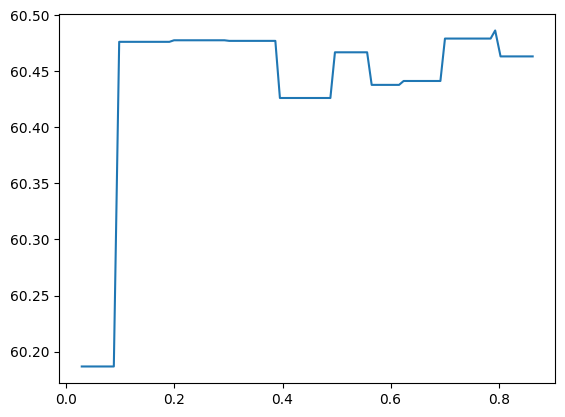

In [11]:
index_of_interest = np.arange(1, 100)
plt.plot(real_data["relative_time"][index_of_interest], real_data["calf_theta32"][index_of_interest])